In [8]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# Parâmetros
k = 10
runs = 2000
steps = 1000
epsilons = [0, 0.01, 0.1]

def run_bandit(epsilon):
    average_rewards = np.zeros(steps)
    optimal_action_counts = np.zeros(steps)

    for run in range(runs):
        q_true = np.random.normal(0, 1, k)
        optimal_action = np.argmax(q_true)

        q_estimates = np.zeros(k)
        action_counts = np.zeros(k)

        for t in range(steps):
            # Política epsilon-greedy
            if np.random.rand() < epsilon:
                action = np.random.randint(k)
            else:
                action = np.argmax(q_estimates)

            reward = np.random.normal(q_true[action], 1)

            action_counts[action] += 1
            q_estimates[action] += (reward - q_estimates[action]) / action_counts[action]

            average_rewards[t] += reward
            if action == optimal_action:
                optimal_action_counts[t] += 1

    average_rewards /= runs
    optimal_action_percentage = (optimal_action_counts / runs) * 100

    return average_rewards, optimal_action_percentage


results = {}

for eps in epsilons:
    avg_r, opt_act = run_bandit(eps)
    results[eps] = (avg_r, opt_act)


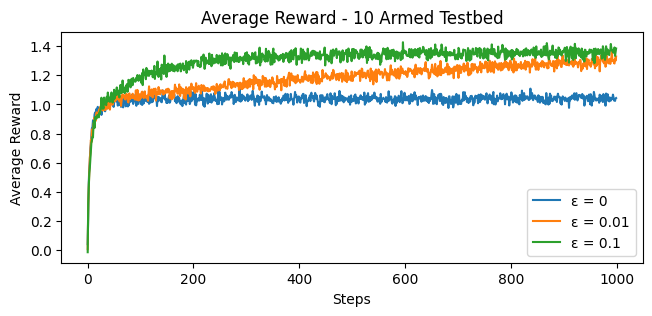

In [16]:
# ---------------------
# Gráfico 1: Average Reward
# ---------------------
plt.figure(figsize=(7.5, 3))
for eps in epsilons:
    plt.plot(results[eps][0], label=f"ε = {eps}")

plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Average Reward - 10 Armed Testbed")
plt.legend()
plt.show()

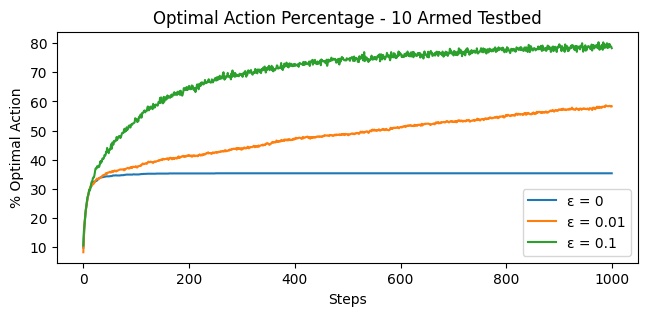

In [17]:
# ---------------------
# Gráfico 2: % Optimal Action
# ---------------------
plt.figure(figsize=(7.5, 3))
for eps in epsilons:
    plt.plot(results[eps][1], label=f"ε = {eps}")

plt.xlabel("Steps")
plt.ylabel("% Optimal Action")
plt.title("Optimal Action Percentage - 10 Armed Testbed")
plt.legend()
plt.show()

In [18]:
# Novos valores de epsilon
new_epsilons = [0.5, 0.001]

for eps in new_epsilons:
    avg_r, opt_act = run_bandit(eps)
    results[eps] = (avg_r, opt_act)

# Lista completa atualizada para plot
all_epsilons = [0, 0.001, 0.01, 0.1, 0.5]

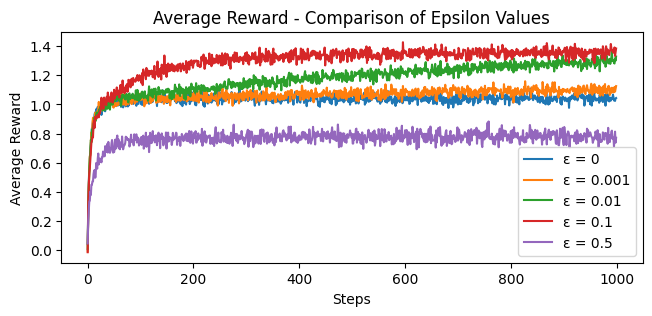

In [22]:
plt.figure(figsize=(7.5, 3))

for eps in all_epsilons:
    plt.plot(results[eps][0], label=f"ε = {eps}")

plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Average Reward - Comparison of Epsilon Values")
plt.legend()
plt.show()

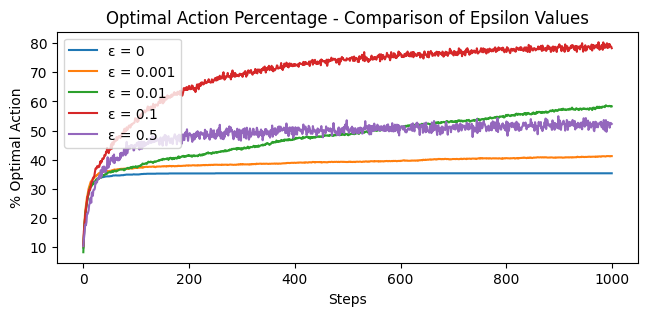

In [23]:
plt.figure(figsize=(7.5, 3))

for eps in all_epsilons:
    plt.plot(results[eps][1], label=f"ε = {eps}")

plt.xlabel("Steps")
plt.ylabel("% Optimal Action")
plt.title("Optimal Action Percentage - Comparison of Epsilon Values")
plt.legend()
plt.show()

## Exercícios

### **a) Altere a simulação para adicionar ε = 0.5 e ε = 0.001. Como ε = 0.5 se compara com ε = 0.1 e ε = 0.01?**

**Resposta:**  
ε = 0.5 explora excessivamente, resultando em menor recompensa média e baixa convergência para a ação ótima quando comparado a ε = 0.1 e ε = 0.01.  
ε = 0.1 apresenta o melhor equilíbrio entre exploração e explotação, enquanto ε = 0.01 converge melhor no longo prazo, porém aprende mais lentamente.

---

### **b) Por que, no começo, ε = 0.1 ganha de ε = 0.01?**

**Resposta:**  
No início, ε = 0.1 explora mais, aumentando a chance de descobrir rapidamente o braço ótimo.  
Já ε = 0.01 explora pouco no começo e pode ficar preso por mais tempo em estimativas iniciais ruins, aprendendo mais devagar.

---

### **c) No longo prazo, quem ganha?**

**Resposta:**  
No longo prazo, quem apresenta melhor desempenho é ε = 0.01 (e ainda mais ε = 0.001), pois exploram muito pouco e, após identificarem a ação ótima, passam a escolhê-la quase sempre, maximizando a recompensa média.
Já ε = 0.1 converge mais rápido, mas mantém exploração constante maior, enquanto ε = 0.5 tem o pior desempenho assintótico por explorar excessivamente, e ε = 0 pode ficar preso em uma ação subótima.

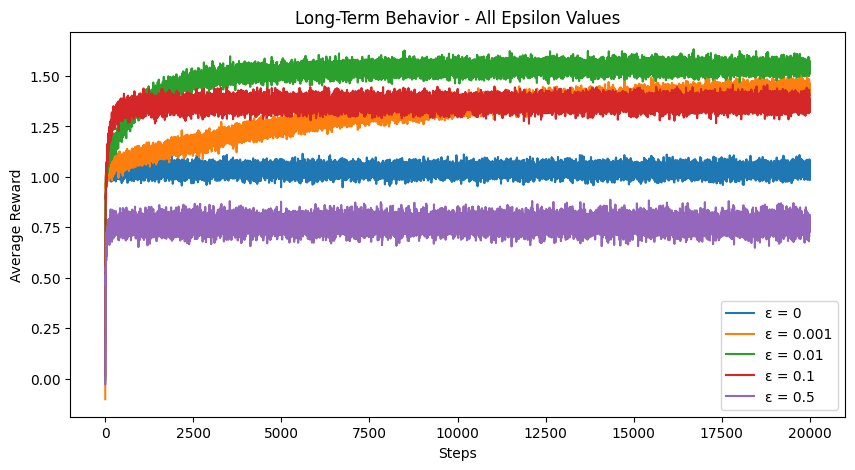

In [24]:
# Simulação de longo prazo
long_steps = 20000
all_epsilons = [0, 0.001, 0.01, 0.1, 0.5]

def run_bandit_long(epsilon):
    average_rewards = np.zeros(long_steps)

    for run in range(runs):
        q_true = np.random.normal(0, 1, k)
        q_estimates = np.zeros(k)
        action_counts = np.zeros(k)

        for t in range(long_steps):
            if np.random.rand() < epsilon:
                action = np.random.randint(k)
            else:
                action = np.argmax(q_estimates)

            reward = np.random.normal(q_true[action], 1)

            action_counts[action] += 1
            q_estimates[action] += (reward - q_estimates[action]) / action_counts[action]

            average_rewards[t] += reward

    return average_rewards / runs


results_long = {}

for eps in all_epsilons:
    results_long[eps] = run_bandit_long(eps)


# Gráfico longo prazo
plt.figure(figsize=(10, 5))

for eps in all_epsilons:
    plt.plot(results_long[eps], label=f"ε = {eps}")

plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Long-Term Behavior - All Epsilon Values")
plt.legend()
plt.show()